# New PLM generation drawing site from entropy

In [1]:
import numpy as np
import torch
import os, platform
import sys
from tqdm import tqdm

import matplotlib.pyplot as plt
from seq_utils import read_tensor_from_txt, set_seed


In [130]:
current_dir = os.getcwd()
parent_dir = os.path.abspath(os.path.join(current_dir, '..'))
sys.path.insert(0, parent_dir)
from model import AttentionModel
from model_PCA_correlation import AttentionModel_PCA
from model_PCA_cond import ModelPCAcondJ
from dcascore import *
from utils import quickread, compute_weights_large
from attention import trainer, trainerCondJ, trainer_PCA_comp_2_model, ar_trainer # choose trainer


# back to original path (in PLM)
sys.path.pop(0)  # Removes the parent_dir from sys.path

'/Users/marzioformica/Desktop/EPFL/Master/StageLBS/PCA_gen_AI/CODE/AttentionDCA_python/src'

## Load Q,K,V

In [3]:
"""
    Load Q, K, V matrices from jdoms (after training)
"""
set_seed()
H = 64
d= 10
N = 174
n_epochs = 500
nb_PCA_comp=2
loss_type = 'without_J'
family = 'jdoms' #'jdoms_bacteria_train2'
cwd = parent_dir
Q_1 = read_tensor_from_txt( cwd +"/results/{H}_{d}_{family}_{losstype}_{n_epochs}_mod_alessandro/Q_tensor.txt".format(H=H, d=d, family=family, losstype=loss_type, n_epochs=n_epochs))
K_1 = read_tensor_from_txt( cwd +"/results/{H}_{d}_{family}_{losstype}_{n_epochs}_mod_alessandro/K_tensor.txt".format(H=H, d=d, family=family, losstype=loss_type, n_epochs=n_epochs))
V_1 = read_tensor_from_txt( cwd +"/results/{H}_{d}_{family}_{losstype}_{n_epochs}_mod_alessandro/V_tensor.txt".format(H=H, d=d, family=family, losstype=loss_type, n_epochs=n_epochs))
H,d,N=Q_1.shape
q=V_1.shape[1]

model=AttentionModel(H,d,N,q,Q=Q_1,V=V_1,K=K_1)
torch.sum(model.Q-Q_1)
device = Q_1.device
L = Q_1.shape[-1]
W=attention_heads_from_model(model,Q_1,K_1,V_1)
print(W.shape)

i_indices = torch.arange(L, device=device).unsqueeze(1)
j_indices = torch.arange(L, device=device).unsqueeze(0)
mask = (i_indices != j_indices).float().unsqueeze(0)  # shape (1, L, L)
# Mask only part without CPA
H, _, M = K_1.shape #(M=N+m)

#W[:,:,:-2] = W[:,:,:-2] * mask
W = W * mask

    
# Compute Jtens
Jtens = torch.einsum('hri,hab->abri', W, V_1)  # Shape: (q, q, L, L)
q = Jtens.shape[0]
N = Jtens.shape[2]
print(q)
print(N)
print(Jtens.shape)

torch.Size([64, 63, 63])
21
63
torch.Size([21, 21, 63, 63])


In [119]:
older_dir = os.path.abspath(os.path.join(current_dir, '..', '..', '..'))
Z,W = quickread(older_dir + '/DataAttentionDCA/jdoms/jdoms_bacteria_train2.fasta')

Total sequences read: 14502
Sequences after filtering: 14502
Sampling 100000 pairs out of 105146751 total pairs.
Mean fraction of identical positions (sampled): 0.371557756293773
Computed theta: 0.3272707888349306


100%|██████████| 14502/14502 [00:09<00:00, 1558.07it/s]

3265.70225762244


In [120]:
def compute_empirical_freqs(Z: np.ndarray, W: np.ndarray, q: int) -> np.ndarray:
    """
    Compute empirical weighted frequencies.
    Z : ndarray of shape (N, M) with entries in [1..q]
    W : ndarray of shape (M,)
    q : alphabet size
    Returns: ndarray of shape (q, N)
    """
    N, M = Z.shape
    if W is None:
        W = np.ones(M) # divide by M at the end
        W = W / M
    else: 
        W = W / W.sum()  # Normalize weights to sum to 1
    # one-hot: (N, M, q)
    Z0 = Z - 1  # shift to 0-based indexing --- IGNORE ---
    one_hot = np.eye(q, dtype=float)[Z0]

    # Multiply weights (broadcast W along N and q)
    weighted = one_hot * W[None, :, None]  # (N, M, q)

    # Sum over sequences (axis=1), result shape (N, q)
    f = weighted.sum(axis=1).T  # (q, N)

    return f

(21, 63)
(63,)


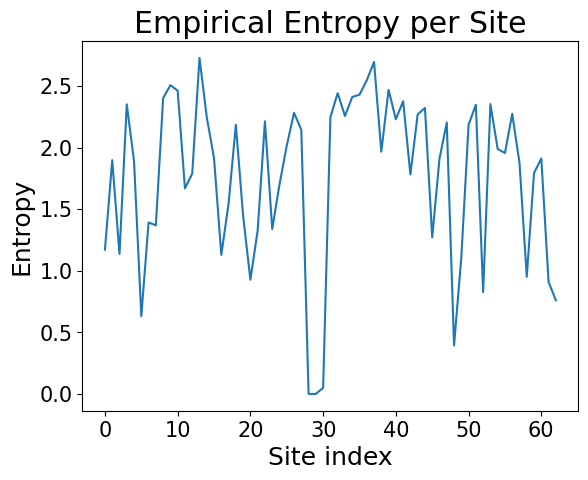

In [121]:
f_emp = compute_empirical_freqs(Z, W, q)
print(f_emp.shape)
probas = f_emp / f_emp.sum(axis=0, keepdims=True)
entropy = -np.sum(probas * np.log(probas + 1e-10), axis=0)  # Adding a small constant to avoid log(0)
print(entropy.shape)
plt.plot(entropy)
plt.xlabel('Site index')
plt.ylabel('Entropy')
plt.title('Empirical Entropy per Site')
plt.show()  

In [163]:
def site_probas(S, beta=1.0):
    """
    Compute site probabilities with temperature scaling.
    S : ndarray of shape (q, N) with empirical frequencies
    beta : inverse temperature
    Returns: ndarray of shape (q, N) with probabilities
    """
    p = np.exp(beta*S)
    probas = p / p.sum(axis=0, keepdims=True)
    return probas

p = site_probas(entropy, beta=1.0)

def beta_tanh(N_iter, N_tot, a=1, asym=False):
    # calculate beta as tanh of iteration ratio
    ratio = N_iter / N_tot
    # shift so that tanh goes from -1 to 1
    #print(a*(ratio-0.5))
    if asym: # less iterations with beta<0 
        beta = np.tanh(a*(ratio-0.25))
    else:
        beta = np.tanh(a*(ratio-0.5))  # scale factor to adjust steepness
    return beta

Text(0.5, 0, 'Iteration ratio')

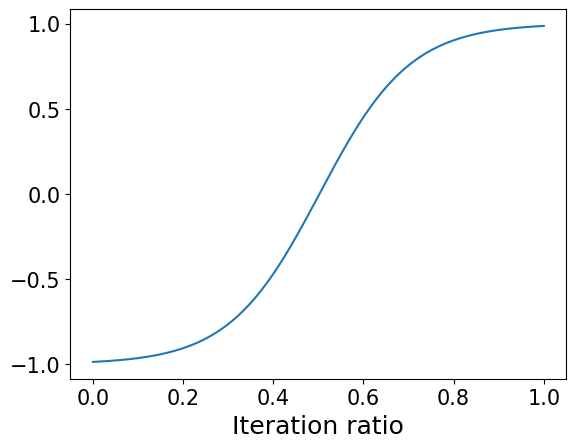

In [164]:
ratio = np.linspace(0, 1, 200)
plt.plot(ratio, beta_tanh(np.arange(200), 200, a=5, asym=False))
plt.xlabel('Iteration ratio')       

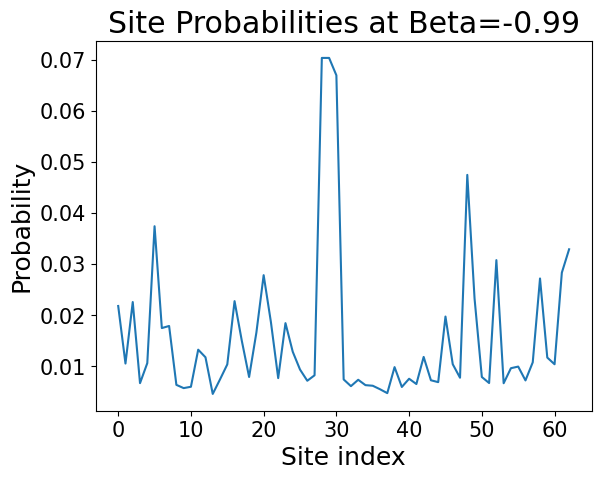

In [165]:
# test plot probas
beta = beta_tanh(2, 200, a=10, asym=False)
# print first 3 digits of beta
b = str(beta)[:5]
p_test = site_probas(entropy, beta=beta)
# plot p_test for all sites
plt.plot(p_test)
plt.xlabel('Site index')
plt.ylabel('Probability')
plt.title('Site Probabilities at Beta={}'.format(b))
plt.show()

In [123]:
class BatchSequencePLMvecc:
    def __init__(self, J, N, beta=1, nb_PCA_comp=0, PCA_component_list=None, J_tens_PCA=None, beta_PCA=1, Z=None):
        """
        Initialize with a batch of N independent sequences.
        """
        self.J = J
        self.J_PCA = J_tens_PCA
        self.beta = beta
        self.beta_PCA = beta_PCA
        self.nb_PCA_comp = nb_PCA_comp
        self.N = N

        if self.J_PCA is not None:
            self.L = J.shape[-1]
        else:
            self.L = J.shape[-1] - nb_PCA_comp

        # Initialize N random sequences
        if Z is None:
            core_sequences = np.random.randint(0, 21, size=(N, self.L))
        else:
            core_sequences = Z[:N, :]

        if nb_PCA_comp > 0:
            if PCA_component_list is None:
                raise ValueError("PCA_component_list must be provided for PCA components.")
            if len(PCA_component_list) != nb_PCA_comp:
                raise ValueError("Mismatch between number of PCA components and list provided.")
            pca_array = np.tile(PCA_component_list, (N, 1))  # replicate for each sequence
            self.sequences = np.concatenate((core_sequences, pca_array), axis=1)
        else:
            self.sequences = core_sequences  # shape: (N, L [+ nb_PCA])

    def plm_site_distribution_batch_vec_full(self, site):
        N, L_total = self.sequences.shape
        L = self.L

        # Indices of other sites
        mask = np.arange(L) != site
        sites_vector = np.arange(L)[mask]           # shape (L-1,)
        aa_vector = self.sequences[:, mask]              # shape (N, L-1)

        # Trial amino acids 0..20
        trial_aa = np.arange(21)[:, None, None]    # shape (21,1,1)

        # Fancy indexing: J[trial_aa, aa_vector, site, sites_vector] -> shape (21, N, L-1)
        energy_matrix = self.J[trial_aa, aa_vector[None, :, :], site, sites_vector[None, :]] * self.beta

        # Sum over other sites
        energies = np.sum(energy_matrix, axis=2).T  # shape (N,21)

        # PCA contributions
        if self.nb_PCA_comp > 0:
            PCA_coords = self.sequences[:, L:L+self.nb_PCA_comp]  # shape (N, nb_PCA_comp)
            if self.J_PCA is not None:
                # Broadcast over trial amino acids and PCA components
                energies += np.sum(self.beta_PCA * self.J_PCA[trial_aa[:, None, None], PCA_coords[None, :, :], site, np.arange(self.nb_PCA_comp)[:, None]], axis=0)
            else:
                # Fallback: use main J tensor for PCA sites
                energies += np.sum(self.beta_PCA * self.J[trial_aa[:, None, None], PCA_coords[None, :, :], site, np.arange(self.L, self.L+self.nb_PCA_comp)[None, :]], axis=0)

        # Softmax with numerical stability
        energies -= energies.max(axis=1, keepdims=True)
        probs = np.exp(energies)
        probs /= probs.sum(axis=1, keepdims=True)
        return probs  # shape (N, 21)
    

    def plm_calc_batch(self, site, trial_aa):
        """
        Compute unnormalized pseudo-likelihood for all N sequences at one site and one trial AA.
        Return: (N,) array
        """
        aa_j_all = self.sequences[:, :self.L]  # shape (N, L)
        aa_trial = np.full(self.N, trial_aa)

        energy = np.zeros(self.N)

        for j in range(self.L):
            if j == site:
                continue
            aa_j = aa_j_all[:, j]  # shape (N,)
            energy += self.beta * np.asarray(self.J[trial_aa, aa_j, site, j])  # vectorized lookup

        # If PCA is used
        if self.nb_PCA_comp > 0:
            for i in range(self.nb_PCA_comp):
                PCA_coord = self.sequences[:, self.L + i]
                if self.J_PCA is not None:
                    energy += self.beta_PCA * np.asarray(self.J_PCA[trial_aa, PCA_coord, site, i])
                else:
                    energy += self.beta_PCA * np.asarray(self.J[trial_aa, PCA_coord, site, self.L + i])
        
        return energy

    def plm_site_distribution_batch(self, site):
        """
        Compute PLM probabilities for each AA (0..20) for all N sequences at site.
        Returns: (N, 21) array of probabilities
        """
        raw_scores = np.zeros((self.N, 21))
        for aa in range(21):
            raw_scores[:, aa] = self.plm_calc_batch(site, aa)

        raw_scores -= raw_scores.max(axis=1, keepdims=True)  # stability
        probs = np.exp(raw_scores)
        probs /= probs.sum(axis=1, keepdims=True)  # normalize
        return probs  # shape: (N, 21)

    def compare_J(self,J ,site):
        """
        Compute PLM probabilities for each AA (0..20) for all N sequences at site.
        Returns: (N, 21) array of probabilities
        """
        prob_list_self_J=self.plm_site_distribution_batch(site)
        raw_scores = np.zeros((self.N, 21))
        for aa in range(21):
            raw_scores[:, aa] = self.plm_calc_batch_diff_J(J,site,aa)

        raw_scores -= raw_scores.max(axis=1, keepdims=True)  # stability
        probs = np.exp(raw_scores)
        probs /= probs.sum(axis=1, keepdims=True)  # normalize
        diff=abs(prob_list_self_J-probs).mean()
        return diff  # shape: (N, 21)

    def assign_seqs(self,sequences):
        self.sequences=sequences

    def draw_aa_batch_old(self, site):
        """
        Sample new AAs for all N sequences at a given site.
        """
        probs = self.plm_site_distribution_batch_vec_full(site)  # (N, 21)
        new_aas = np.array([np.random.choice(21, p=p) for p in probs])  # (N,)
        self.sequences[:, site] = new_aas

    def draw_aa_batch(self, site):
        """
        Sample new AAs for all N sequences at a given site.
        Fully vectorized using cumulative probabilities + argmax.
        """
        probs = self.plm_site_distribution_batch_vec_full(site)  # (N, 21)
        probs_old = self.plm_site_distribution_batch(site)  # (N, 21) old implementation for comparison
        assert np.allclose(probs, probs_old), "Mismatch between vectorized and looped PLM distribution"
        #print("Vectorized PLM distribution matches looped version.")
        cum_probs = np.cumsum(probs, axis=1)  # (N, 21)
        r = np.random.rand(probs.shape[0])    # (N,)
        new_aas = (cum_probs >= r[:, None]).argmax(axis=1)  # (N,)
        self.sequences[:, site] = new_aas

    def compare_draw(self,site):
        """
        Compare old and new draw methods.
        """
        for _ in range(5):  # repeat a few times to average out randomness; draw then check at the end
            self.draw_aa_batch_old(site)
            self.draw_aa_batch(site)
            # store drawn aas
            aas_old = self.sequences[:, site].copy()
            aas_new = self.sequences[:, site].copy()
            if not np.array_equal(aas_old, aas_new):
                print("Mismatch in drawn AAs!")
            else:
                print("Drawn AAs match.")

    def evolve_all(self, n_iter=500):
        """
        Perform Gibbs sampling over all sequences for n_iter iterations.
        """
        for _ in tqdm(range(n_iter)):
            site=np.random.choice(self.L)
            self.draw_aa_batch(site)

    def get_sequences(self):
        """
        Return all N sequences.
        """
        return self.sequences

    def to_letters(self):
        """
        Return N sequences in letter format.
        """
        num_to_letter = {v: k for k, v in letter_to_num.items()}
        letter_seqs = []
        for seq in self.sequences[:, :self.L]:
            letter_seq = ''.join([num_to_letter[i] for i in seq])
            letter_seqs.append(letter_seq)
        return letter_seqs

In [149]:
#from plm_model import BatchSequencePLMvec

def generate_plm_last_seq(J, Nseqs=1000, steps=2000, beta=1, site_selector=None):
    """
    Generate Nseqs sequences, each evolved for 'steps' iterations.
    Returns only the final sequence for each.
    """
    L = J.shape[2]  # sequence length
    sequences = [] #np.random.randint(21, size=(Nseqs, L))  # random initialization
    SeqBatch = BatchSequencePLMvecc(J, Nseqs, beta=beta, Z=Z.copy().T)
    for i in tqdm(range(steps)):
        # pick random site per iteration (could vectorize multiple sites if desired)
        if site_selector is None:
            site = np.random.randint(L)  # uniform random
        else:
            if i < steps/2*0:
                site = np.random.randint(L)
            else:
                beta_site = beta_tanh(i, steps, a=3, asym=False)
                probas = site_probas(entropy, beta=beta_site)
                site = np.random.choice(L, p=probas)  # weighted random
                #print("Selected site:", site)
                site = int(site)
        SeqBatch.draw_aa_batch(site)
        #SeqBatch.compare_draw(site)
        sequences.append(SeqBatch.get_sequences())
            #plm = BatchSequencePLMvec(J, Nseqs, beta=beta)        
        # compute PLM probabilities for all sequences at this site
        #probs = plm_site_distribution_batch_vec_full(sequences, J, site, beta)  # vectorized
        
        # vectorized sampling
        #cum_probs = np.cumsum(probs, axis=1)
        #r = np.random.rand(Nseqs)
        #sequences[:, site] = np.argmax(cum_probs >= r[:, None], axis=1)
    sequences = np.array(sequences[-1])  # return only the last sequences
    return sequences

gen_seqs_batch = generate_plm_last_seq(Jtens.cpu().numpy(), Nseqs=10000, steps=3000, beta=1, site_selector=1)
print(gen_seqs_batch.shape)

100%|██████████| 3000/3000 [2:49:23<00:00,  3.39s/it]      

(10000, 63)


In [ ]:
def generate_plm_vec(J, N_seqs=40000, init_sequence=None, beta=1, nb_PCA_comp=0, beta_pca = 0, target_coords=np.array([]), site_selector=None):
    """
    Generate N_seqs new sequences using PLM.

    Parameters
    ----------
    J : interaction tensor
    N_seqs : int
        Number of sequences to generate
    init_sequence : array-like
        Optional initial sequence
    beta : float
        Inverse temperature
    site_selector : function(seq) -> int
        Function to select site to update.
        If None, sites are chosen uniformly at random.
    """
    gen_sequences = []
    seq = SequencePLMvec(J, init_sequence, beta=beta, nb_PCA_comp=nb_PCA_comp, target_coords=target_coords, beta_PCA=beta_pca)

    for i in tqdm(range(N_seqs)):
        if site_selector is None:
            site = np.random.randint(seq.L)  # uniform random
        else:
            beta = beta_tanh(i, N_seqs, a=3, asym=False)
            probas = site_probas(entropy, beta=beta)
            site = np.random.choice(seq.L, p=probas)  # weighted random
            #print("Selected site:", site)
            site = int(site)
        #seq.check_vectorized(site)
        seq.draw_aa(site, vec=True)
        gen_sequences.append(seq.sequence.copy())

    return np.array(gen_sequences)

In [39]:
from plm_model import SequencePLMvec
generated_seqs = generate_plm_vec(Jtens.cpu().numpy(), N_seqs=1000000, beta=1, site_selector=1)

100%|██████████| 1000000/1000000 [02:16<00:00, 7323.52it/s]


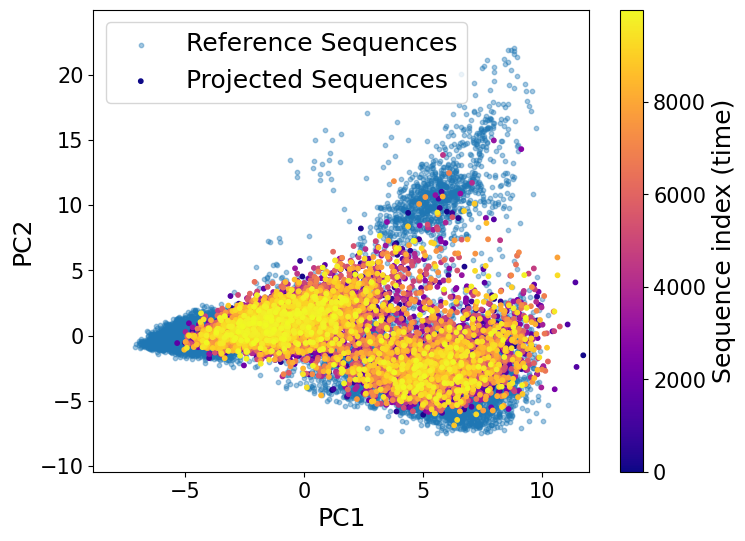

In [150]:
from PCA_func import plot_projected_pca, plot_pca_of_sequences, plot_two_pca_side_by_side, plot_projected_pca_mult, plot_projected_pca_time
#plot_projected_pca_time(Z.T,np.array(generated_seqs[::10], dtype=int))
plot_projected_pca_time(Z.T,np.array(gen_seqs_batch, dtype=int))

(21, 63)
Sampling 100000 pairs out of 49995000 total pairs.
Mean fraction of identical positions (sampled): 0.31767853708359794
Computed theta: 0.38277688230477036
θ = 0.38277688230477036 threshold = 24.0


 11%|█▏        | 1140/10000 [00:00<00:07, 1168.05it/s]

Processing sequence 1000/10000


 23%|██▎       | 2292/10000 [00:01<00:05, 1492.98it/s]

Processing sequence 2000/10000


...

Processing sequence 6000/10000


 77%|███████▋  | 7687/10000 [00:03<00:00, 3903.51it/s]

Processing sequence 7000/10000
Processing sequence 8000/10000


100%|██████████| 10000/10000 [00:04<00:00, 2356.80it/s]


Processing sequence 9000/10000
Processing sequence 10000/10000
M = 10000 N = 63 Meff = 9626.965624522822
(21, 63)


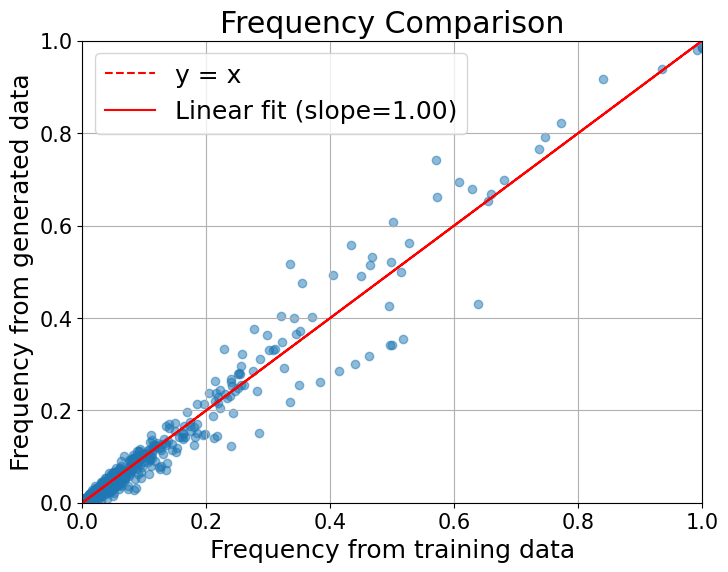

In [166]:
f_train = compute_empirical_freqs(Z, W, q=21)
f_train_flat = f_train.flatten()
print(f_train.shape)


W_gen,_ = compute_weights_large(gen_seqs_batch.T, theta='auto')
f_gen = compute_empirical_freqs(np.array(gen_seqs_batch.T, dtype=int), W_gen, q=21)
f_gen_flat = f_gen.flatten()
print(f_gen.shape)

plt.figure(figsize=(8, 6))
plt.scatter(f_train_flat, f_gen_flat, alpha=0.5)
plt.xlabel('Frequency from training data')
plt.ylabel('Frequency from generated data')
plt.title('Frequency Comparison')

# y=x reference line
plt.plot([0, 1], [0, 1], 'r--', label='y = x')

# linear fit
m, b = np.polyfit(f_train_flat, f_gen_flat, 1)
plt.plot(f_train_flat, m*f_train_flat + b, color='red',label=f'Linear fit (slope={m:.2f})')

plt.xlim(0, 1)
plt.ylim(0, 1)
plt.grid(True)
plt.legend()
plt.show()

In [87]:
batch_copy = gen_seqs_batch.copy()

In [95]:
batch_rev_copy = gen_seqs_batch.copy()

In [62]:
from hamming_dist import hamming_dist, energy_corr_array
initial_sequence = np.array(gen_seqs_batch[0], dtype=int)
hamming_distances = []
for seq in np.array(gen_seqs_batch,dtype=int):
    distance = hamming_dist(initial_sequence, seq)
    hamming_distances.append(distance)
hamming_distances = np.array(hamming_distances)
correlation = energy_corr_array(hamming_distances, int(len(hamming_distances)/5))

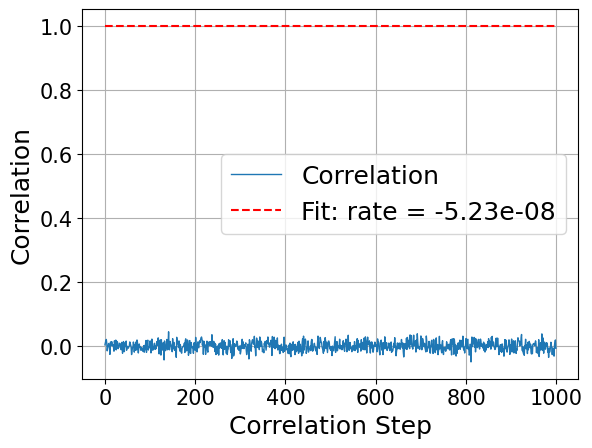

In [61]:

from scipy.stats import linregress
 
def plot_decorrelation(correlation,range,save_path=None):
    x_vals = np.arange(range)  # X values for linear fit (steps)
    y_vals = correlation[:range]  # First 1000 correlation values
    
    # Perform linear fit: y = mx + c, extract the slope (m)
    slope, intercept, r_value, p_value, std_err = linregress(x_vals, np.exp(y_vals))
    
    # Store the slope for this beta
    
    
    # Plot the correlation curve and linear fit
    plt.plot(correlation, marker='', linestyle='-', linewidth=1, label="Correlation")
    plt.plot(np.arange(len(correlation)), np.exp(slope * np.arange(len(correlation))), color='r',linestyle="--", label=f"Fit: rate = {slope:.2e}")
    plt.xlabel("Correlation Step")
    plt.ylabel("Correlation")
    plt.legend()
    plt.grid(True)
    if save_path:
        plt.savefig(save_path)
    plt.show()
    
plot_decorrelation(correlation, int(len(hamming_distances)/5), save_path=None)